In [1]:
import pandas as pd
import numpy as np
import subprocess
import os
from datetime import datetime, timedelta, time, date
import datetime
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Datos de filtros
fecha_i = '20260531'
fecha_f = '20260531'

In [3]:
#Tipo día

tipo_dia = pd.read_csv('Z:/01 base_datos/41 Informe Diario CCZ/2023/IRI TM/Tipo día.csv', encoding='latin', delimiter=';')

tipo_dia

,Fecha,Día,Tipo Día
0,1/01/2016,Viernes,Festivo
1,2/01/2016,Sábado,Sábado
2,3/01/2016,Domingo,Festivo
3,4/01/2016,Lunes,Hábil
4,5/01/2016,Martes,Hábil
...,...,...,...
4013,27/12/2026,Domingo,Festivo
4014,28/12/2026,Lunes,Hábil
4015,29/12/2026,Martes,Hábil
4016,30/12/2026,Miércoles,Hábil


In [4]:
# Supongamos que 'df' es tu DataFrame y 'Fecha' es la columna que necesitas convertir
tipo_dia['Fecha'] = pd.to_datetime(tipo_dia['Fecha'], format='%d/%m/%Y', errors='coerce')

tipo_dia

,Fecha,Día,Tipo Día
0,2016-01-01,Viernes,Festivo
1,2016-01-02,Sábado,Sábado
2,2016-01-03,Domingo,Festivo
3,2016-01-04,Lunes,Hábil
4,2016-01-05,Martes,Hábil
...,...,...,...
4013,2026-12-27,Domingo,Festivo
4014,2026-12-28,Lunes,Hábil
4015,2026-12-29,Martes,Hábil
4016,2026-12-30,Miércoles,Hábil


In [5]:
# Ruta de la carpeta que contiene los archivos
ruta_carpeta = 'Z:/01 base_datos/18 pasajeros_asociados'

# Fechas de inicio y fin para el filtro
fecha_inicio = f'{fecha_i}'
fecha_fin = f'{fecha_f}'

# Lista para almacenar los DataFrames
dataframes = []

# Recorrer todos los archivos en la carpeta
for nombre_archivo in os.listdir(ruta_carpeta):
    if nombre_archivo.endswith('_pax_asociados.csv'):
        # Extraer la fecha del nombre del archivo
        fecha_archivo = nombre_archivo[:8]  
        
        # Convertir la fecha a un formato adecuado para comparación
        fecha_archivo_dt = pd.to_datetime(fecha_archivo, format='%Y%m%d', errors='coerce')

        # Verificar si la fecha está dentro del rango deseado
        if fecha_inicio <= fecha_archivo <= fecha_fin:
            ruta_archivo = os.path.join(ruta_carpeta, nombre_archivo)
            df = pd.read_csv(ruta_archivo, encoding='latin', low_memory=False)
            dataframes.append(df)

# Verificar si se encontraron DataFrames
if dataframes:
    # Consolidar todos los DataFrames en uno solo
    pasajeros = pd.concat(dataframes, ignore_index=True)

    # # Guardar el DataFrame consolidado en un nuevo archivo
    # pasajeros.to_csv('C:/Users/Jonny Villareal/OneDrive - Gmovil SAS/Escritorio/Jonny/Intentos/Omision_Paradas/Actividad_bus.csv', index=False)
else:
    print("No se encontraron archivos para consolidar.")
    
pasajeros

,FechaId,Fecha,NumeroBus,ServicioBus,LineAso,RutaAso,RutaOrg,LineaOrg,IdViaje,Conductor,FechaReal,IdViajeGrupo,HoraInicio,StrParadero,Paradero,TipoValidacion,TipoOperacion
0,20260531,2026-05-31,507090,CE0D80001,10354.0,10674,10674,16-5,2.0,508023.0,2026-05-31T04:00:19Z,2026-05-31507090CE0D80001-2,03:30,(51163) 044A04_TM|044A04_Villas de AlcalÃ¡,51163.0,Transbordo,PADRON ZONAL
1,20260531,2026-05-31,507090,CE0D80001,10354.0,10674,10674,16-5,2.0,508023.0,2026-05-31T04:04:02Z,2026-05-31507090CE0D80001-2,03:30,(52843) 243A05_TM|243A05_Br. MarandÃº,52843.0,Transbordo,PADRON ZONAL
2,20260531,2026-05-31,507090,CE0D80001,10354.0,10674,10674,16-5,2.0,508023.0,2026-05-31T04:04:26Z,2026-05-31507090CE0D80001-2,03:30,(52843) 243A05_TM|243A05_Br. MarandÃº,52843.0,Transbordo,PADRON ZONAL
3,20260531,2026-05-31,507090,CE0D80001,10354.0,10674,10674,16-5,2.0,508023.0,2026-05-31T04:05:22Z,2026-05-31507090CE0D80001-2,03:30,(52813) 232A05_TM|232A05_Br. MarandÃº,52813.0,Transbordo,PADRON ZONAL
4,20260531,2026-05-31,507092,CE0D80002,10354.0,10674,10674,16-5,2.0,505499.0,2026-05-31T04:12:07Z,2026-05-31507092CE0D80002-2,03:30,(58134) 451A04_TM|451A04_Gran Granada,58134.0,Transbordo,PADRON ZONAL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77209,20260531,2026-05-31,504497,NaN,NaN,12789,12789,577,NaN,NaN,2026-05-31T20:28:09Z,NaN,NaN,(53840) 117B08_TM|117B08_IED Kennedy,53840.0,Transbordo,BUSETON ZONAL
77210,20260531,2026-05-31,504497,NaN,NaN,12789,12789,577,NaN,NaN,2026-05-31T20:34:19Z,NaN,NaN,(53843) 119B08_TM|119B08_Br. Techo,53843.0,Viaje Inicial,BUSETON ZONAL
77211,20260531,2026-05-31,504497,NaN,NaN,12789,12789,577,NaN,NaN,2026-05-31T20:37:00Z,NaN,NaN,(54079) 202A08_TM|202A08_Br. Ciudad Kennedy Ce...,54079.0,Transbordo,BUSETON ZONAL
77212,20260531,2026-05-31,504497,NaN,NaN,12789,12789,577,NaN,NaN,2026-05-31T21:11:24Z,NaN,NaN,(53555) 433A06_TM|433A06_IED Costa Rica,53555.0,Transbordo,BUSETON ZONAL


In [6]:
# Convertir la columna 'Instante' a un objeto datetime
pasajeros['FechaReal'] = pd.to_datetime(pasajeros['FechaReal'])

# Crear nuevas columnas para la fecha y la hora
pasajeros['Fecha_N'] = pasajeros['FechaReal'].dt.strftime('%d/%m/%Y').str.lstrip('0').replace('/0', '/')
pasajeros['Hora'] = pasajeros['FechaReal'].dt.strftime('%H:%M:%S')

# Mostrar el DataFrame con las nuevas columnas
pasajeros

,FechaId,Fecha,NumeroBus,ServicioBus,LineAso,RutaAso,RutaOrg,LineaOrg,IdViaje,Conductor,FechaReal,IdViajeGrupo,HoraInicio,StrParadero,Paradero,TipoValidacion,TipoOperacion,Fecha_N,Hora
0,20260531,2026-05-31,507090,CE0D80001,10354.0,10674,10674,16-5,2.0,508023.0,2026-05-31 04:00:19+00:00,2026-05-31507090CE0D80001-2,03:30,(51163) 044A04_TM|044A04_Villas de AlcalÃ¡,51163.0,Transbordo,PADRON ZONAL,31/05/2026,04:00:19
1,20260531,2026-05-31,507090,CE0D80001,10354.0,10674,10674,16-5,2.0,508023.0,2026-05-31 04:04:02+00:00,2026-05-31507090CE0D80001-2,03:30,(52843) 243A05_TM|243A05_Br. MarandÃº,52843.0,Transbordo,PADRON ZONAL,31/05/2026,04:04:02
2,20260531,2026-05-31,507090,CE0D80001,10354.0,10674,10674,16-5,2.0,508023.0,2026-05-31 04:04:26+00:00,2026-05-31507090CE0D80001-2,03:30,(52843) 243A05_TM|243A05_Br. MarandÃº,52843.0,Transbordo,PADRON ZONAL,31/05/2026,04:04:26
3,20260531,2026-05-31,507090,CE0D80001,10354.0,10674,10674,16-5,2.0,508023.0,2026-05-31 04:05:22+00:00,2026-05-31507090CE0D80001-2,03:30,(52813) 232A05_TM|232A05_Br. MarandÃº,52813.0,Transbordo,PADRON ZONAL,31/05/2026,04:05:22
4,20260531,2026-05-31,507092,CE0D80002,10354.0,10674,10674,16-5,2.0,505499.0,2026-05-31 04:12:07+00:00,2026-05-31507092CE0D80002-2,03:30,(58134) 451A04_TM|451A04_Gran Granada,58134.0,Transbordo,PADRON ZONAL,31/05/2026,04:12:07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77209,20260531,2026-05-31,504497,NaN,NaN,12789,12789,577,NaN,NaN,2026-05-31 20:28:09+00:00,NaN,NaN,(53840) 117B08_TM|117B08_IED Kennedy,53840.0,Transbordo,BUSETON ZONAL,31/05/2026,20:28:09
77210,20260531,2026-05-31,504497,NaN,NaN,12789,12789,577,NaN,NaN,2026-05-31 20:34:19+00:00,NaN,NaN,(53843) 119B08_TM|119B08_Br. Techo,53843.0,Viaje Inicial,BUSETON ZONAL,31/05/2026,20:34:19
77211,20260531,2026-05-31,504497,NaN,NaN,12789,12789,577,NaN,NaN,2026-05-31 20:37:00+00:00,NaN,NaN,(54079) 202A08_TM|202A08_Br. Ciudad Kennedy Ce...,54079.0,Transbordo,BUSETON ZONAL,31/05/2026,20:37:00
77212,20260531,2026-05-31,504497,NaN,NaN,12789,12789,577,NaN,NaN,2026-05-31 21:11:24+00:00,NaN,NaN,(53555) 433A06_TM|433A06_IED Costa Rica,53555.0,Transbordo,BUSETON ZONAL,31/05/2026,21:11:24


In [7]:
# Función para corregir las horas
def corregir_horas(hora):
    partes = hora.split(':')
    horas = int(partes[0])
    if horas >= 24:
        horas = horas % 24
    return f'{horas:02d}:{partes[1]}:{partes[2]}'

# Aplicar la función a la columna 'Horas'
pasajeros['Hora'] = pasajeros['Hora'].apply(corregir_horas)

pasajeros['Hora1']  = pasajeros['Hora'] 

pasajeros['validacion'] = 1

pasajeros

,FechaId,Fecha,NumeroBus,ServicioBus,LineAso,RutaAso,RutaOrg,LineaOrg,IdViaje,Conductor,...,IdViajeGrupo,HoraInicio,StrParadero,Paradero,TipoValidacion,TipoOperacion,Fecha_N,Hora,Hora1,validacion
0,20260531,2026-05-31,507090,CE0D80001,10354.0,10674,10674,16-5,2.0,508023.0,...,2026-05-31507090CE0D80001-2,03:30,(51163) 044A04_TM|044A04_Villas de AlcalÃ¡,51163.0,Transbordo,PADRON ZONAL,31/05/2026,04:00:19,04:00:19,1
1,20260531,2026-05-31,507090,CE0D80001,10354.0,10674,10674,16-5,2.0,508023.0,...,2026-05-31507090CE0D80001-2,03:30,(52843) 243A05_TM|243A05_Br. MarandÃº,52843.0,Transbordo,PADRON ZONAL,31/05/2026,04:04:02,04:04:02,1
2,20260531,2026-05-31,507090,CE0D80001,10354.0,10674,10674,16-5,2.0,508023.0,...,2026-05-31507090CE0D80001-2,03:30,(52843) 243A05_TM|243A05_Br. MarandÃº,52843.0,Transbordo,PADRON ZONAL,31/05/2026,04:04:26,04:04:26,1
3,20260531,2026-05-31,507090,CE0D80001,10354.0,10674,10674,16-5,2.0,508023.0,...,2026-05-31507090CE0D80001-2,03:30,(52813) 232A05_TM|232A05_Br. MarandÃº,52813.0,Transbordo,PADRON ZONAL,31/05/2026,04:05:22,04:05:22,1
4,20260531,2026-05-31,507092,CE0D80002,10354.0,10674,10674,16-5,2.0,505499.0,...,2026-05-31507092CE0D80002-2,03:30,(58134) 451A04_TM|451A04_Gran Granada,58134.0,Transbordo,PADRON ZONAL,31/05/2026,04:12:07,04:12:07,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77209,20260531,2026-05-31,504497,NaN,NaN,12789,12789,577,NaN,NaN,...,NaN,NaN,(53840) 117B08_TM|117B08_IED Kennedy,53840.0,Transbordo,BUSETON ZONAL,31/05/2026,20:28:09,20:28:09,1
77210,20260531,2026-05-31,504497,NaN,NaN,12789,12789,577,NaN,NaN,...,NaN,NaN,(53843) 119B08_TM|119B08_Br. Techo,53843.0,Viaje Inicial,BUSETON ZONAL,31/05/2026,20:34:19,20:34:19,1
77211,20260531,2026-05-31,504497,NaN,NaN,12789,12789,577,NaN,NaN,...,NaN,NaN,(54079) 202A08_TM|202A08_Br. Ciudad Kennedy Ce...,54079.0,Transbordo,BUSETON ZONAL,31/05/2026,20:37:00,20:37:00,1
77212,20260531,2026-05-31,504497,NaN,NaN,12789,12789,577,NaN,NaN,...,NaN,NaN,(53555) 433A06_TM|433A06_IED Costa Rica,53555.0,Transbordo,BUSETON ZONAL,31/05/2026,21:11:24,21:11:24,1


In [8]:
# Función para corregir tiempos con "24:00:00"
def fix_time(date_str):
    if '24:' in date_str:
        return date_str.replace('24:', '00:')
    elif '25:' in date_str:
        return date_str.replace('25:', '01:')
    elif '26:' in date_str:
        return date_str.replace('26:', '02:')
    elif '27:' in date_str:
        return date_str.replace('27:', '03:')
    elif '28:' in date_str:
        return date_str.replace('28:', '04:')
    elif '29:' in date_str:
        return date_str.replace('29:', '05:')
    else:
        return date_str

# Función para convertir tiempo a segundos
def time_to_seconds(time_obj):
    return time_obj.hour * 3600 + time_obj.minute * 60 + time_obj.second

# Función para convertir segundos a horas, minutos y segundos
def seconds_to_hms(seconds):
    hours = seconds // 3600
    minutes = (seconds % 3600) // 60
    seconds = seconds % 60
    return hours, minutes, seconds

# Convertir las columnas de tiempo a cadenas
pasajeros['Hora'] = pasajeros['Hora'].astype(str)

# Aplicar la función para corregir los tiempos en 'HoraLlegada'
pasajeros['Hora'] = pasajeros['Hora'].apply(fix_time)

# Convertir las columnas de tiempo a datetime (sin fecha, solo tiempo)
pasajeros['Hora'] = pd.to_datetime(pasajeros['Hora'], format='%H:%M:%S').dt.time

pasajeros['Horas_Minutos_Segundos'] = pasajeros['Hora'].apply(time_to_seconds)

pasajeros

,FechaId,Fecha,NumeroBus,ServicioBus,LineAso,RutaAso,RutaOrg,LineaOrg,IdViaje,Conductor,...,HoraInicio,StrParadero,Paradero,TipoValidacion,TipoOperacion,Fecha_N,Hora,Hora1,validacion,Horas_Minutos_Segundos
0,20260531,2026-05-31,507090,CE0D80001,10354.0,10674,10674,16-5,2.0,508023.0,...,03:30,(51163) 044A04_TM|044A04_Villas de AlcalÃ¡,51163.0,Transbordo,PADRON ZONAL,31/05/2026,04:00:19,04:00:19,1,14419
1,20260531,2026-05-31,507090,CE0D80001,10354.0,10674,10674,16-5,2.0,508023.0,...,03:30,(52843) 243A05_TM|243A05_Br. MarandÃº,52843.0,Transbordo,PADRON ZONAL,31/05/2026,04:04:02,04:04:02,1,14642
2,20260531,2026-05-31,507090,CE0D80001,10354.0,10674,10674,16-5,2.0,508023.0,...,03:30,(52843) 243A05_TM|243A05_Br. MarandÃº,52843.0,Transbordo,PADRON ZONAL,31/05/2026,04:04:26,04:04:26,1,14666
3,20260531,2026-05-31,507090,CE0D80001,10354.0,10674,10674,16-5,2.0,508023.0,...,03:30,(52813) 232A05_TM|232A05_Br. MarandÃº,52813.0,Transbordo,PADRON ZONAL,31/05/2026,04:05:22,04:05:22,1,14722
4,20260531,2026-05-31,507092,CE0D80002,10354.0,10674,10674,16-5,2.0,505499.0,...,03:30,(58134) 451A04_TM|451A04_Gran Granada,58134.0,Transbordo,PADRON ZONAL,31/05/2026,04:12:07,04:12:07,1,15127
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77209,20260531,2026-05-31,504497,NaN,NaN,12789,12789,577,NaN,NaN,...,NaN,(53840) 117B08_TM|117B08_IED Kennedy,53840.0,Transbordo,BUSETON ZONAL,31/05/2026,20:04:09,20:28:09,1,72249
77210,20260531,2026-05-31,504497,NaN,NaN,12789,12789,577,NaN,NaN,...,NaN,(53843) 119B08_TM|119B08_Br. Techo,53843.0,Viaje Inicial,BUSETON ZONAL,31/05/2026,20:34:19,20:34:19,1,74059
77211,20260531,2026-05-31,504497,NaN,NaN,12789,12789,577,NaN,NaN,...,NaN,(54079) 202A08_TM|202A08_Br. Ciudad Kennedy Ce...,54079.0,Transbordo,BUSETON ZONAL,31/05/2026,20:37:00,20:37:00,1,74220
77212,20260531,2026-05-31,504497,NaN,NaN,12789,12789,577,NaN,NaN,...,NaN,(53555) 433A06_TM|433A06_IED Costa Rica,53555.0,Transbordo,BUSETON ZONAL,31/05/2026,21:11:24,21:11:24,1,76284


In [9]:
# Eliminar columnas específicas
columnas_a_eliminar = ['FechaId', 'IdViajeGrupo', 'HoraInicio', 'TipoOperacion','FechaReal']
pasajeros = pasajeros.drop(columns=columnas_a_eliminar)

pasajeros

,Fecha,NumeroBus,ServicioBus,LineAso,RutaAso,RutaOrg,LineaOrg,IdViaje,Conductor,StrParadero,Paradero,TipoValidacion,Fecha_N,Hora,Hora1,validacion,Horas_Minutos_Segundos
0,2026-05-31,507090,CE0D80001,10354.0,10674,10674,16-5,2.0,508023.0,(51163) 044A04_TM|044A04_Villas de AlcalÃ¡,51163.0,Transbordo,31/05/2026,04:00:19,04:00:19,1,14419
1,2026-05-31,507090,CE0D80001,10354.0,10674,10674,16-5,2.0,508023.0,(52843) 243A05_TM|243A05_Br. MarandÃº,52843.0,Transbordo,31/05/2026,04:04:02,04:04:02,1,14642
2,2026-05-31,507090,CE0D80001,10354.0,10674,10674,16-5,2.0,508023.0,(52843) 243A05_TM|243A05_Br. MarandÃº,52843.0,Transbordo,31/05/2026,04:04:26,04:04:26,1,14666
3,2026-05-31,507090,CE0D80001,10354.0,10674,10674,16-5,2.0,508023.0,(52813) 232A05_TM|232A05_Br. MarandÃº,52813.0,Transbordo,31/05/2026,04:05:22,04:05:22,1,14722
4,2026-05-31,507092,CE0D80002,10354.0,10674,10674,16-5,2.0,505499.0,(58134) 451A04_TM|451A04_Gran Granada,58134.0,Transbordo,31/05/2026,04:12:07,04:12:07,1,15127
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77209,2026-05-31,504497,NaN,NaN,12789,12789,577,NaN,NaN,(53840) 117B08_TM|117B08_IED Kennedy,53840.0,Transbordo,31/05/2026,20:04:09,20:28:09,1,72249
77210,2026-05-31,504497,NaN,NaN,12789,12789,577,NaN,NaN,(53843) 119B08_TM|119B08_Br. Techo,53843.0,Viaje Inicial,31/05/2026,20:34:19,20:34:19,1,74059
77211,2026-05-31,504497,NaN,NaN,12789,12789,577,NaN,NaN,(54079) 202A08_TM|202A08_Br. Ciudad Kennedy Ce...,54079.0,Transbordo,31/05/2026,20:37:00,20:37:00,1,74220
77212,2026-05-31,504497,NaN,NaN,12789,12789,577,NaN,NaN,(53555) 433A06_TM|433A06_IED Costa Rica,53555.0,Transbordo,31/05/2026,21:11:24,21:11:24,1,76284


In [10]:
# Filtrar el DataFrame para mantener solo las filas donde 'ServicioBus' no es NaN
pasajeros = pasajeros[pasajeros['ServicioBus'].notna()]

In [11]:
# Crear la columna 'Franja' extrayendo la hora
pasajeros['Franja'] = pasajeros['Hora1'].str[:2]

pasajeros['LineAso'].fillna(0, inplace=True)
pasajeros['LineAso'] = pasajeros['LineAso'].astype(int)

pasajeros['RutaOrg'].fillna(0, inplace=True)
pasajeros['RutaOrg'] = pasajeros['RutaOrg'].astype(int)

pasajeros['IdViaje'] = pasajeros['IdViaje'].astype(int)

pasajeros

C:\Users\Jonny Villareal\AppData\Local\Temp\ipykernel_29844\1082029109.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pasajeros['Franja'] = pasajeros['Hora1'].str[:2]
C:\Users\Jonny Villareal\AppData\Local\Temp\ipykernel_29844\1082029109.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original objec

,Fecha,NumeroBus,ServicioBus,LineAso,RutaAso,RutaOrg,LineaOrg,IdViaje,Conductor,StrParadero,Paradero,TipoValidacion,Fecha_N,Hora,Hora1,validacion,Horas_Minutos_Segundos,Franja
0,2026-05-31,507090,CE0D80001,10354,10674,10674,16-5,2,508023.0,(51163) 044A04_TM|044A04_Villas de AlcalÃ¡,51163.0,Transbordo,31/05/2026,04:00:19,04:00:19,1,14419,04
1,2026-05-31,507090,CE0D80001,10354,10674,10674,16-5,2,508023.0,(52843) 243A05_TM|243A05_Br. MarandÃº,52843.0,Transbordo,31/05/2026,04:04:02,04:04:02,1,14642,04
2,2026-05-31,507090,CE0D80001,10354,10674,10674,16-5,2,508023.0,(52843) 243A05_TM|243A05_Br. MarandÃº,52843.0,Transbordo,31/05/2026,04:04:26,04:04:26,1,14666,04
3,2026-05-31,507090,CE0D80001,10354,10674,10674,16-5,2,508023.0,(52813) 232A05_TM|232A05_Br. MarandÃº,52813.0,Transbordo,31/05/2026,04:05:22,04:05:22,1,14722,04
4,2026-05-31,507092,CE0D80002,10354,10674,10674,16-5,2,505499.0,(58134) 451A04_TM|451A04_Gran Granada,58134.0,Transbordo,31/05/2026,04:12:07,04:12:07,1,15127,04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77035,2026-05-31,504464,CE1700010,10292,12790,12790,577,6,510140.0,(54982) 032A10_TM|032A10_Br. La Laguna,54982.0,Transbordo,31/05/2026,23:18:55,23:18:55,1,83935,23
77036,2026-05-31,502072,CE1AF0003,10244,12741,12741,SE10,8,510551.0,(51349) 115B04_TM|115B04_Br. Santa MarÃ­a,51349.0,Transbordo,31/05/2026,23:19:10,23:19:10,1,83950,23
77037,2026-05-31,507014,CE16B0005,10194,12786,12786,539,8,506530.0,(53327) 039B12_TM|039B12_IED Miguel de Cervantes,53327.0,Viaje Inicial,31/05/2026,23:04:13,23:28:13,1,83053,23
77038,2026-05-31,507053,CE1590006,10204,12776,12776,402,6,508745.0,(52730) 191A05_TM|191A05_Br. Villa Luz,52730.0,Transbordo,31/05/2026,23:04:58,23:28:58,1,83098,23


In [12]:
pasajeros['Franja'] = pasajeros['Franja'].astype(int)

C:\Users\Jonny Villareal\AppData\Local\Temp\ipykernel_29844\3263317416.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pasajeros['Franja'] = pasajeros['Franja'].astype(int)


In [13]:
#Verificar y ajustar los tipos de datos

print(pasajeros[['Fecha_N', 'NumeroBus', 'LineAso','RutaOrg','IdViaje','Horas_Minutos_Segundos','Franja' ]].dtypes)

Fecha_N                   object
NumeroBus                  int64
LineAso                    int32
RutaOrg                    int32
IdViaje                    int32
Horas_Minutos_Segundos     int64
Franja                     int32
dtype: object


C:\Users\Jonny Villareal\AppData\Local\Temp\ipykernel_29844\3472796204.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(x='Franja', y='validacion', data=franja_agg, palette='viridis')


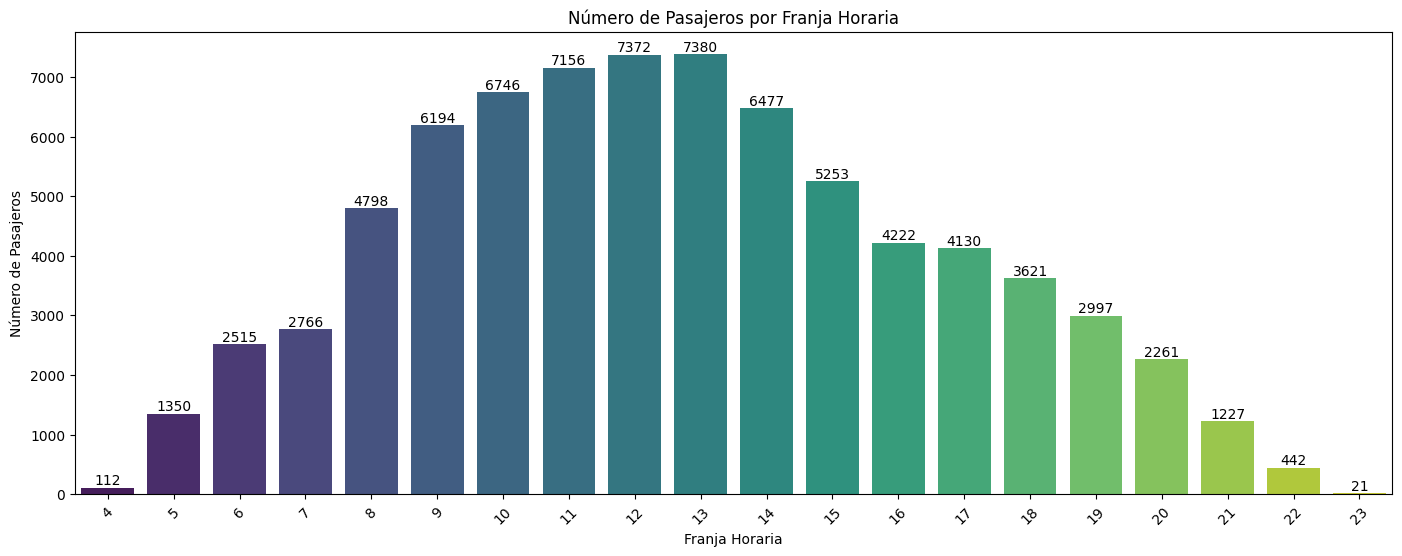

In [14]:
# Agrupar los datos por 'Franja' y sumar el número de pasajeros
franja_agg = pasajeros.groupby('Franja')['validacion'].sum().reset_index()

# Crear el gráfico de barras
plt.figure(figsize=(17, 6))
barplot = sns.barplot(x='Franja', y='validacion', data=franja_agg, palette='viridis')

# Personalizar el gráfico
plt.title('Número de Pasajeros por Franja Horaria')
plt.xlabel('Franja Horaria')
plt.ylabel('Número de Pasajeros')
plt.xticks(rotation=45)

# Agregar etiquetas de datos en las barras
for index, row in franja_agg.iterrows():
    barplot.text(index, row['validacion'], round(row['validacion'], 2), color='black', ha="center", va="bottom")

plt.show()

C:\Users\Jonny Villareal\AppData\Local\Temp\ipykernel_29844\839781931.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(x='LineaOrg', y='validacion', data=franja_agg, palette='viridis')


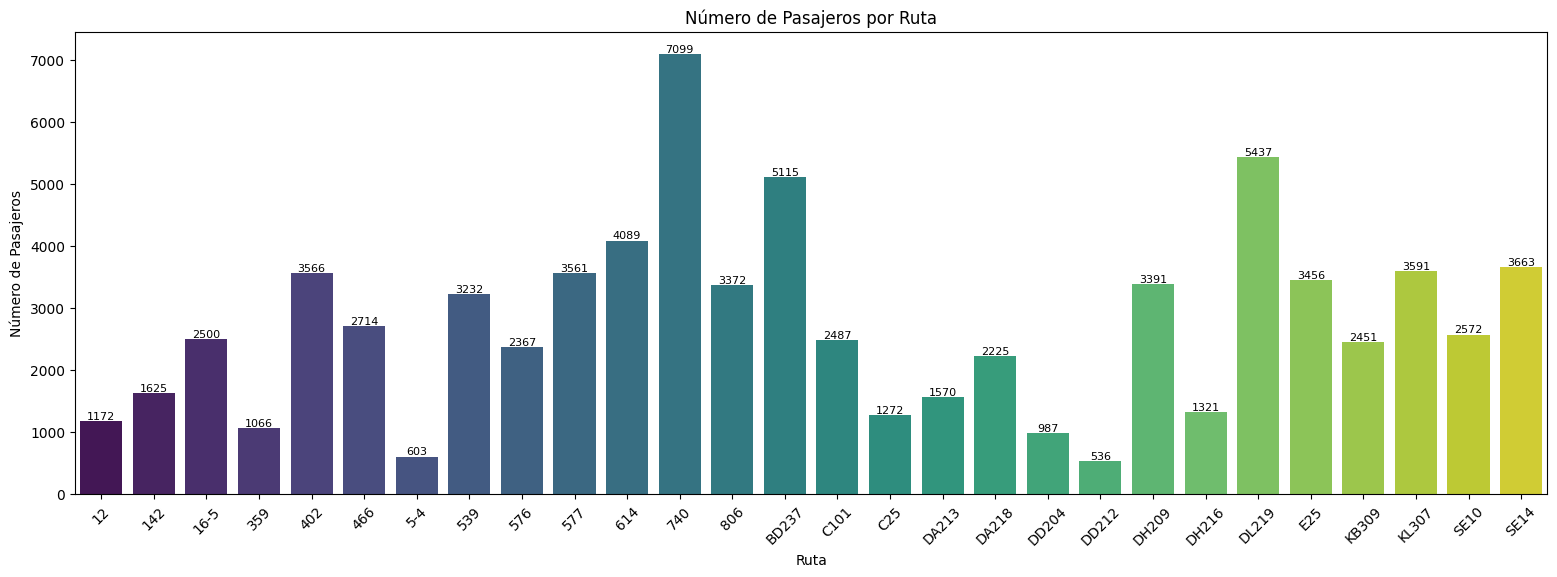

In [15]:
# Agrupar los datos por 'Franja' y sumar el número de pasajeros
franja_agg = pasajeros.groupby('LineaOrg')['validacion'].sum().reset_index()

# Crear el gráfico de barras
plt.figure(figsize=(19, 6))
barplot = sns.barplot(x='LineaOrg', y='validacion', data=franja_agg, palette='viridis')

# Personalizar el gráfico
plt.title('Número de Pasajeros por Ruta')
plt.xlabel('Ruta')
plt.ylabel('Número de Pasajeros')
plt.xticks(rotation=45)

# Agregar etiquetas de datos en las barras
for index, row in franja_agg.iterrows():
    barplot.text(index, row['validacion'], round(row['validacion'], 2), color='black', ha="center", va="bottom", fontsize=8)

plt.show()

C:\Users\Jonny Villareal\AppData\Local\Temp\ipykernel_29844\412939633.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(x='Franja', y='validacion', data=franja_agg, palette='viridis')


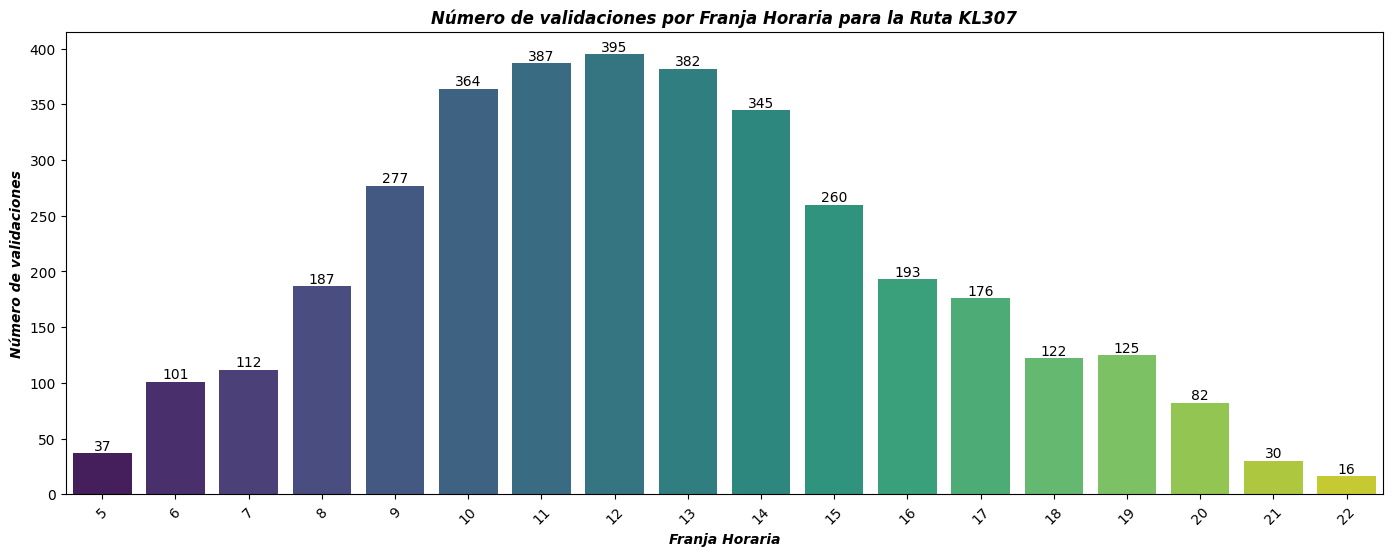

In [16]:
# Rutas
ruta_filtrada = 'KL307'  

# Filtrar el DataFrame por la ruta seleccionada
quejas_filtradas = pasajeros[pasajeros['LineaOrg'] == ruta_filtrada]

# Agrupar los datos por 'Franja' y sumar el número de pasajeros.
franja_agg = quejas_filtradas.groupby('Franja')['validacion'].sum().reset_index()

# Crear el gráfico de barras
plt.figure(figsize=(17, 6))
barplot = sns.barplot(x='Franja', y='validacion', data=franja_agg, palette='viridis')

# Personalizar el gráfico
plt.title(f'Número de validaciones por Franja Horaria para la Ruta {ruta_filtrada}',fontweight='bold', style='italic')
plt.xlabel('Franja Horaria',fontweight='bold', style='italic')
plt.ylabel('Número de validaciones',fontweight='bold', style='italic')
plt.xticks(rotation=45)

# Agregar etiquetas de datos en las barras
for index, row in franja_agg.iterrows():
    barplot.text(index, row['validacion'], round(row['validacion'], 2), color='black', ha="center", va="bottom")

# Mostrar el gráfico
plt.show()

In [17]:
pasajeros

,Fecha,NumeroBus,ServicioBus,LineAso,RutaAso,RutaOrg,LineaOrg,IdViaje,Conductor,StrParadero,Paradero,TipoValidacion,Fecha_N,Hora,Hora1,validacion,Horas_Minutos_Segundos,Franja
0,2026-05-31,507090,CE0D80001,10354,10674,10674,16-5,2,508023.0,(51163) 044A04_TM|044A04_Villas de AlcalÃ¡,51163.0,Transbordo,31/05/2026,04:00:19,04:00:19,1,14419,4
1,2026-05-31,507090,CE0D80001,10354,10674,10674,16-5,2,508023.0,(52843) 243A05_TM|243A05_Br. MarandÃº,52843.0,Transbordo,31/05/2026,04:04:02,04:04:02,1,14642,4
2,2026-05-31,507090,CE0D80001,10354,10674,10674,16-5,2,508023.0,(52843) 243A05_TM|243A05_Br. MarandÃº,52843.0,Transbordo,31/05/2026,04:04:26,04:04:26,1,14666,4
3,2026-05-31,507090,CE0D80001,10354,10674,10674,16-5,2,508023.0,(52813) 232A05_TM|232A05_Br. MarandÃº,52813.0,Transbordo,31/05/2026,04:05:22,04:05:22,1,14722,4
4,2026-05-31,507092,CE0D80002,10354,10674,10674,16-5,2,505499.0,(58134) 451A04_TM|451A04_Gran Granada,58134.0,Transbordo,31/05/2026,04:12:07,04:12:07,1,15127,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77035,2026-05-31,504464,CE1700010,10292,12790,12790,577,6,510140.0,(54982) 032A10_TM|032A10_Br. La Laguna,54982.0,Transbordo,31/05/2026,23:18:55,23:18:55,1,83935,23
77036,2026-05-31,502072,CE1AF0003,10244,12741,12741,SE10,8,510551.0,(51349) 115B04_TM|115B04_Br. Santa MarÃ­a,51349.0,Transbordo,31/05/2026,23:19:10,23:19:10,1,83950,23
77037,2026-05-31,507014,CE16B0005,10194,12786,12786,539,8,506530.0,(53327) 039B12_TM|039B12_IED Miguel de Cervantes,53327.0,Viaje Inicial,31/05/2026,23:04:13,23:28:13,1,83053,23
77038,2026-05-31,507053,CE1590006,10204,12776,12776,402,6,508745.0,(52730) 191A05_TM|191A05_Br. Villa Luz,52730.0,Transbordo,31/05/2026,23:04:58,23:28:58,1,83098,23


In [18]:
# Supongamos que 'df' es tu DataFrame y 'Fecha' es la columna que necesitas convertir
pasajeros['Fecha_N'] = pd.to_datetime(pasajeros['Fecha_N'], format='%d/%m/%Y', errors='coerce')

pasajeros

C:\Users\Jonny Villareal\AppData\Local\Temp\ipykernel_29844\1204886226.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pasajeros['Fecha_N'] = pd.to_datetime(pasajeros['Fecha_N'], format='%d/%m/%Y', errors='coerce')


,Fecha,NumeroBus,ServicioBus,LineAso,RutaAso,RutaOrg,LineaOrg,IdViaje,Conductor,StrParadero,Paradero,TipoValidacion,Fecha_N,Hora,Hora1,validacion,Horas_Minutos_Segundos,Franja
0,2026-05-31,507090,CE0D80001,10354,10674,10674,16-5,2,508023.0,(51163) 044A04_TM|044A04_Villas de AlcalÃ¡,51163.0,Transbordo,2026-05-31,04:00:19,04:00:19,1,14419,4
1,2026-05-31,507090,CE0D80001,10354,10674,10674,16-5,2,508023.0,(52843) 243A05_TM|243A05_Br. MarandÃº,52843.0,Transbordo,2026-05-31,04:04:02,04:04:02,1,14642,4
2,2026-05-31,507090,CE0D80001,10354,10674,10674,16-5,2,508023.0,(52843) 243A05_TM|243A05_Br. MarandÃº,52843.0,Transbordo,2026-05-31,04:04:26,04:04:26,1,14666,4
3,2026-05-31,507090,CE0D80001,10354,10674,10674,16-5,2,508023.0,(52813) 232A05_TM|232A05_Br. MarandÃº,52813.0,Transbordo,2026-05-31,04:05:22,04:05:22,1,14722,4
4,2026-05-31,507092,CE0D80002,10354,10674,10674,16-5,2,505499.0,(58134) 451A04_TM|451A04_Gran Granada,58134.0,Transbordo,2026-05-31,04:12:07,04:12:07,1,15127,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77035,2026-05-31,504464,CE1700010,10292,12790,12790,577,6,510140.0,(54982) 032A10_TM|032A10_Br. La Laguna,54982.0,Transbordo,2026-05-31,23:18:55,23:18:55,1,83935,23
77036,2026-05-31,502072,CE1AF0003,10244,12741,12741,SE10,8,510551.0,(51349) 115B04_TM|115B04_Br. Santa MarÃ­a,51349.0,Transbordo,2026-05-31,23:19:10,23:19:10,1,83950,23
77037,2026-05-31,507014,CE16B0005,10194,12786,12786,539,8,506530.0,(53327) 039B12_TM|039B12_IED Miguel de Cervantes,53327.0,Viaje Inicial,2026-05-31,23:04:13,23:28:13,1,83053,23
77038,2026-05-31,507053,CE1590006,10204,12776,12776,402,6,508745.0,(52730) 191A05_TM|191A05_Br. Villa Luz,52730.0,Transbordo,2026-05-31,23:04:58,23:28:58,1,83098,23


In [19]:
pasajeros['Paradero'] = pasajeros['Paradero'].fillna(0)

pasajeros['Paradero'] = pasajeros['Paradero'].astype(int)

C:\Users\Jonny Villareal\AppData\Local\Temp\ipykernel_29844\1594411021.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pasajeros['Paradero'] = pasajeros['Paradero'].fillna(0)
C:\Users\Jonny Villareal\AppData\Local\Temp\ipykernel_29844\1594411021.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pasajeros['Paradero'] = pasajeros['Paradero'].astype(int)


In [20]:
def calcular_max_linea(fecha):
    # Filtro para el DataFrame combinado
    filtro = (
        (tipo_dia['Fecha'] == fecha)
    )
    
    # Filtrar el DataFrame acb según el filtro
    resultado = tipo_dia.loc[filtro, 'Tipo Día']
    
    # Verificar si hay algún resultado después de aplicar el filtro
    if not resultado.empty:
        # Obtener el valor 
        return resultado.max()
    
    return None  # Devolver None si no hay resultados

# Aplica la función a las columnas correspondientes en fonias
pasajeros['Tipo Día'] = pasajeros.apply(
    lambda row: calcular_max_linea(
        row['Fecha_N']
    ),
    axis=1
)

pasajeros

C:\Users\Jonny Villareal\AppData\Local\Temp\ipykernel_29844\1752775172.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pasajeros['Tipo Día'] = pasajeros.apply(


,Fecha,NumeroBus,ServicioBus,LineAso,RutaAso,RutaOrg,LineaOrg,IdViaje,Conductor,StrParadero,Paradero,TipoValidacion,Fecha_N,Hora,Hora1,validacion,Horas_Minutos_Segundos,Franja,Tipo Día
0,2026-05-31,507090,CE0D80001,10354,10674,10674,16-5,2,508023.0,(51163) 044A04_TM|044A04_Villas de AlcalÃ¡,51163,Transbordo,2026-05-31,04:00:19,04:00:19,1,14419,4,Festivo
1,2026-05-31,507090,CE0D80001,10354,10674,10674,16-5,2,508023.0,(52843) 243A05_TM|243A05_Br. MarandÃº,52843,Transbordo,2026-05-31,04:04:02,04:04:02,1,14642,4,Festivo
2,2026-05-31,507090,CE0D80001,10354,10674,10674,16-5,2,508023.0,(52843) 243A05_TM|243A05_Br. MarandÃº,52843,Transbordo,2026-05-31,04:04:26,04:04:26,1,14666,4,Festivo
3,2026-05-31,507090,CE0D80001,10354,10674,10674,16-5,2,508023.0,(52813) 232A05_TM|232A05_Br. MarandÃº,52813,Transbordo,2026-05-31,04:05:22,04:05:22,1,14722,4,Festivo
4,2026-05-31,507092,CE0D80002,10354,10674,10674,16-5,2,505499.0,(58134) 451A04_TM|451A04_Gran Granada,58134,Transbordo,2026-05-31,04:12:07,04:12:07,1,15127,4,Festivo
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77035,2026-05-31,504464,CE1700010,10292,12790,12790,577,6,510140.0,(54982) 032A10_TM|032A10_Br. La Laguna,54982,Transbordo,2026-05-31,23:18:55,23:18:55,1,83935,23,Festivo
77036,2026-05-31,502072,CE1AF0003,10244,12741,12741,SE10,8,510551.0,(51349) 115B04_TM|115B04_Br. Santa MarÃ­a,51349,Transbordo,2026-05-31,23:19:10,23:19:10,1,83950,23,Festivo
77037,2026-05-31,507014,CE16B0005,10194,12786,12786,539,8,506530.0,(53327) 039B12_TM|039B12_IED Miguel de Cervantes,53327,Viaje Inicial,2026-05-31,23:04:13,23:28:13,1,83053,23,Festivo
77038,2026-05-31,507053,CE1590006,10204,12776,12776,402,6,508745.0,(52730) 191A05_TM|191A05_Br. Villa Luz,52730,Transbordo,2026-05-31,23:04:58,23:28:58,1,83098,23,Festivo


In [21]:
#resumen por ruta puntos de alta demanda

# Agrupar los datos por LineAso, RutaOrg, Paradero, StrParadero, Franja y sumar las validaciones
resumen = pasajeros.groupby(['LineaOrg','LineAso', 'RutaOrg', 'Paradero', 'StrParadero', 'Franja'])['validacion'].sum().reset_index()

# Ordenar por LineAso, RutaOrg y validacion en orden descendente para obtener el top 10
resumen_ordenado = resumen.sort_values(by=['LineAso', 'RutaOrg', 'validacion'], ascending=[True, True, False])

# Obtener el top 10 por cada LineAso y RutaOrg
top_10 = resumen_ordenado.groupby(['LineAso', 'RutaOrg']).head(10)

# Mostrar la tabla resumen
top_10

,LineaOrg,LineAso,RutaOrg,Paradero,StrParadero,Franja,validacion
9376,740,10184,12774,52638,(52638) 168B05_TM|168B05_Avenida Calle 26,14,55
10494,740,10184,12774,56330,(56330) 123A07_TM|123A07_Biblioteca el Tintal,12,49
10053,740,10184,12774,55056,(55056) 077A10_TM|077A10_Br. Santander,16,42
9377,740,10184,12774,52638,(52638) 168B05_TM|168B05_Avenida Calle 26,15,38
9488,740,10184,12774,52806,(52806) 222A05_TM|222A05_Hospital de EngativÃ¡...,8,32
...,...,...,...,...,...,...,...
15480,DA218,10691,12750,51355,(51355) 117B04_TM|117B04_CAI Las Ferias,14,14
15641,DA218,10691,12750,52718,(52718) 183C05_TM|183C05_Br. Ferias,8,14
15660,DA218,10691,12750,52842,(52842) 242A05_TM|242A05_Br. MarandÃº,13,14
15486,DA218,10691,12750,51358,(51358) 118B04_TM|118B04_Br. Las Ferias,14,13


In [22]:
# Agrupar los datos por LineAso, RutaOrg, Paradero, StrParadero, Franja y calcular el promedio de las validaciones
resumen = pasajeros.groupby(['Tipo Día','LineaOrg', 'LineAso', 'RutaOrg', 'Paradero', 'StrParadero', 'Franja'])['validacion'].sum().reset_index()

# Ordenar por LineAso, RutaOrg y validacion (promedio) en orden descendente para obtener el top 10
resumen_ordenado = resumen.sort_values(by=['LineAso', 'RutaOrg', 'validacion'], ascending=[True, True, False])

# Obtener el top 10 por cada LineAso y RutaOrg
top_10 = resumen_ordenado.groupby(['LineAso', 'RutaOrg']).head(10)

# Mostrar la tabla resumen con el top 10
top_10

,Tipo Día,LineaOrg,LineAso,RutaOrg,Paradero,StrParadero,Franja,validacion
9376,Festivo,740,10184,12774,52638,(52638) 168B05_TM|168B05_Avenida Calle 26,14,55
10494,Festivo,740,10184,12774,56330,(56330) 123A07_TM|123A07_Biblioteca el Tintal,12,49
10053,Festivo,740,10184,12774,55056,(55056) 077A10_TM|077A10_Br. Santander,16,42
9377,Festivo,740,10184,12774,52638,(52638) 168B05_TM|168B05_Avenida Calle 26,15,38
9488,Festivo,740,10184,12774,52806,(52806) 222A05_TM|222A05_Hospital de EngativÃ¡...,8,32
...,...,...,...,...,...,...,...,...
15480,Festivo,DA218,10691,12750,51355,(51355) 117B04_TM|117B04_CAI Las Ferias,14,14
15641,Festivo,DA218,10691,12750,52718,(52718) 183C05_TM|183C05_Br. Ferias,8,14
15660,Festivo,DA218,10691,12750,52842,(52842) 242A05_TM|242A05_Br. MarandÃº,13,14
15486,Festivo,DA218,10691,12750,51358,(51358) 118B04_TM|118B04_Br. Las Ferias,14,13


In [23]:
top_10.to_csv(f'C:/Users/Jonny Villareal/OneDrive - Gmovil SAS/Escritorio/Jonny/Intentos/Omision_Paradas/puntos_max_carga_{fecha_i}.csv', index=False)

In [24]:
# pasajeros.to_csv('C:/Users/Jonny Villareal/OneDrive - Gmovil SAS/Escritorio/Jonny/Intentos/Omision_Paradas/puntos_max_carga_2024.csv', index=False)